In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'credit' in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/creditcard.csv/creditcard.csv


In [5]:
df = pd.read_csv('/content/drive/MyDrive/creditcard.csv/creditcard.csv')
print(df.shape)
print(df.head())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [6]:
fraud_count = df['Class'].value_counts()
print(fraud_count)
print()
print(f"Fraud percentage: {fraud_count[1] / len(df) * 100:.4f}%")

Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


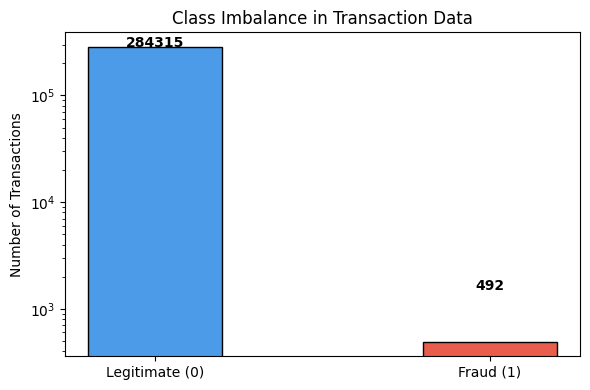

In [7]:
import matplotlib.pyplot as plt

labels = ['Legitimate (0)', 'Fraud (1)']
counts = [284315, 492]
colors = ['#4C9BE8', '#E85D4C']

plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=colors, edgecolor='black', width=0.4)
plt.title('Class Imbalance in Transaction Data')
plt.ylabel('Number of Transactions')
plt.yscale('log')

for i, count in enumerate(counts):
    plt.text(i, count + 1000, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

print("Fraud transactions:")
print(fraud.describe())
print()
print("Legitimate transactions:")
print(legit.describe())

Fraud transactions:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Legitimate transactions:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

df_clean = df.drop(['Amount', 'Time'], axis=1)

print(df_clean.shape)
print(df_clean.head())

(284807, 31)
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28  Class  Amount_scaled  

In [10]:
from sklearn.model_selection import train_test_split

X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Frauds in training set: {y_train.sum()}")
print(f"Frauds in test set: {y_test.sum()}")

Training set size: (227845, 30)
Test set size: (56962, 30)
Frauds in training set: 394
Frauds in test set: 98


In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE - Legitimate: {(y_train == 0).sum()}, Fraud: {(y_train == 1).sum()}")
print(f"After SMOTE  - Legitimate: {(y_train_resampled == 0).sum()}, Fraud: {(y_train_resampled == 1).sum()}")

Before SMOTE - Legitimate: 227451, Fraud: 394
After SMOTE  - Legitimate: 227451, Fraud: 227451


LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



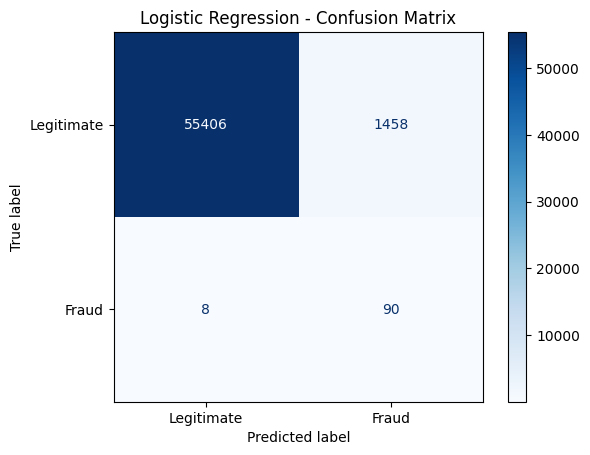

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr_model.predict(X_test)

print("LOGISTIC REGRESSION RESULTS")
print("="*40)
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



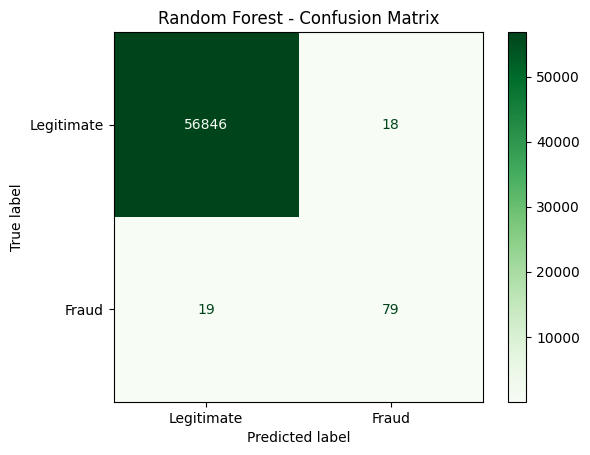

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test)

print("RANDOM FOREST RESULTS")
print("="*40)
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Legitimate', 'Fraud'])
disp_rf.plot(cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.show()

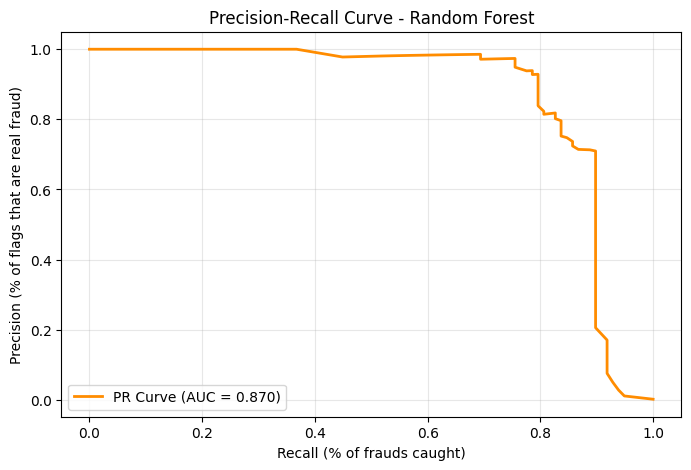


PR-AUC Score: 0.870


In [14]:
from sklearn.metrics import precision_recall_curve, auc
import numpy as np

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)
pr_auc = auc(recalls, precisions)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color='darkorange', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall (% of frauds caught)')
plt.ylabel('Precision (% of flags that are real fraud)')
plt.title('Precision-Recall Curve - Random Forest')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nPR-AUC Score: {pr_auc:.3f}")

In [15]:
# Business cost assumptions
COST_MISSED_FRAUD = 500      # cost of missing a fraud (£500 lost)
COST_FALSE_ALARM = 10        # cost of wrongly blocking a legit customer (support call, churn risk)

best_threshold = 0.5
best_cost = float('inf')
results = []

for threshold in thresholds:
    y_pred_thresh = (y_proba_rf >= threshold).astype(int)

    tn = ((y_pred_thresh == 0) & (y_test == 0)).sum()
    fp = ((y_pred_thresh == 1) & (y_test == 0)).sum()
    fn = ((y_pred_thresh == 0) & (y_test == 1)).sum()
    tp = ((y_pred_thresh == 1) & (y_test == 1)).sum()

    total_cost = (fn * COST_MISSED_FRAUD) + (fp * COST_FALSE_ALARM)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    results.append({
        'threshold': round(threshold, 3),
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'missed_frauds': fn,
        'false_alarms': fp,
        'total_cost': total_cost
    })

    if total_cost < best_cost:
        best_cost = total_cost
        best_threshold = threshold

results_df = pd.DataFrame(results)
print(f"Optimal threshold: {best_threshold:.3f}")
print(f"Minimum business cost: £{best_cost:,.0f}")
print()
print("Sample of thresholds and their business impact:")
print(results_df[['threshold','precision','recall','missed_frauds','false_alarms','total_cost']].iloc[::20].to_string(index=False))

Optimal threshold: 0.290
Minimum business cost: £5,360

Sample of thresholds and their business impact:
 threshold  precision  recall  missed_frauds  false_alarms  total_cost
      0.00      0.002   1.000              0         56864      568640
      0.20      0.603   0.898             10            58        5580
      0.48      0.818   0.827             17            18        8680
      0.84      0.972   0.714             28             2       14020


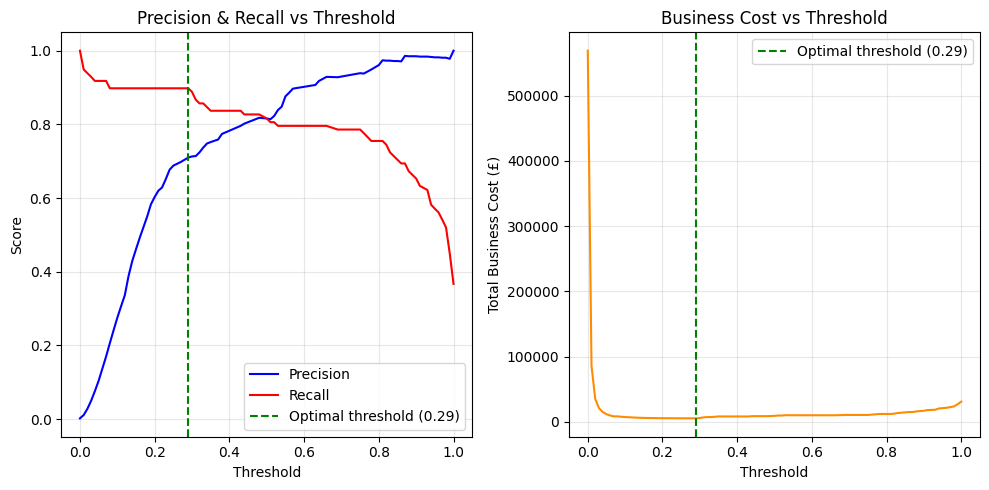

In [16]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(results_df['threshold'], results_df['precision'], label='Precision', color='blue')
plt.plot(results_df['threshold'], results_df['recall'], label='Recall', color='red')
plt.axvline(x=best_threshold, color='green', linestyle='--', label=f'Optimal threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(results_df['threshold'], results_df['total_cost'], color='darkorange')
plt.axvline(x=best_threshold, color='green', linestyle='--', label=f'Optimal threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Total Business Cost (£)')
plt.title('Business Cost vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

FINAL MODEL PERFORMANCE AT THRESHOLD 0.29
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.71      0.90      0.79        98

    accuracy                           1.00     56962
   macro avg       0.85      0.95      0.90     56962
weighted avg       1.00      1.00      1.00     56962



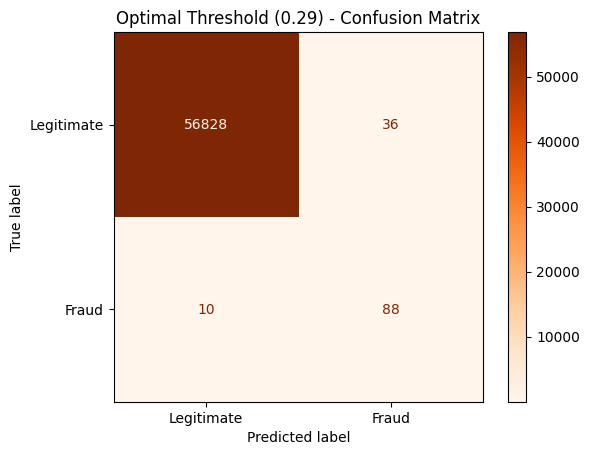

Frauds caught: 88 out of 98 (89.8%)
False alarms: 36 out of 56864 legitimate transactions (0.063%)
Business cost at default threshold (0.5): £8,680
Business cost at optimal threshold: £5,360


In [17]:
y_pred_optimal = (y_proba_rf >= best_threshold).astype(int)

print(f"FINAL MODEL PERFORMANCE AT THRESHOLD {best_threshold:.2f}")
print("="*50)
print(classification_report(y_test, y_pred_optimal, target_names=['Legitimate', 'Fraud']))

cm_optimal = confusion_matrix(y_test, y_pred_optimal)
disp_optimal = ConfusionMatrixDisplay(confusion_matrix=cm_optimal, display_labels=['Legitimate', 'Fraud'])
disp_optimal.plot(cmap='Oranges')
plt.title(f'Optimal Threshold ({best_threshold:.2f}) - Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm_optimal.ravel()
print(f"Frauds caught: {tp} out of {tp+fn} ({tp/(tp+fn)*100:.1f}%)")
print(f"False alarms: {fp} out of {tn+fp} legitimate transactions ({fp/(tn+fp)*100:.3f}%)")
print(f"Business cost at default threshold (0.5): £{results_df[results_df['threshold']==0.48]['total_cost'].values[0]:,.0f}")
print(f"Business cost at optimal threshold: £{best_cost:,.0f}")